# 站点地理信息可视化分析

本笔记本结合 `data/raw/geo_data/stations.csv` 中的地理信息，分析 `data/processed/all_data.parquet` 中涉及的112个站点的分布情况。

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 读取地理数据
geo_df = pd.read_csv('../data/raw/geo_data/stations.csv')

# 读取气象数据
meteo_df = pd.read_parquet('../data/processed/all_data.parquet')

# 从气象数据列名中提取站点代码
stations_in_meteo = set([col.split('~')[0] for col in meteo_df.columns])
stations_in_meteo = sorted(list(stations_in_meteo))

print(f'气象数据中包含的站点数: {len(stations_in_meteo)}')
print(f'地理数据中包含的站点数: {len(geo_df)}')

气象数据中包含的站点数: 112
地理数据中包含的站点数: 302


## 1. 站点匹配分析

In [ ]:
# 提取地理数据中的站点代码
stations_in_geo = set(geo_df['nat_abbr'])

# 检查匹配情况
matched_stations = set(stations_in_meteo) & stations_in_geo
unmatched_stations = set(stations_in_meteo) - stations_in_geo

print(f'匹配的站点数: {len(matched_stations)}')
print(f'未匹配的站点数: {len(unmatched_stations)}')

if unmatched_stations:
    print('未匹配的站点:', sorted(list(unmatched_stations)))

# 过滤出匹配的地理数据
matched_geo_df = geo_df[geo_df['nat_abbr'].isin(stations_in_meteo)].copy()
print(f'匹配后的地理数据行数: {len(matched_geo_df)}')

匹配的站点数: 112
未匹配的站点数: 0
匹配后的地理数据行数: 112


## 2. 站点地理分布

In [ ]:
import folium
from folium.plugins import MarkerCluster

# 创建地图
m = folium.Map(location=[46.8, 8.2], zoom_start=8, tiles='OpenStreetMap')

# 添加站点标记
marker_cluster = MarkerCluster().add_to(m)

for idx, row in matched_geo_df.iterrows():
    station_code = row['nat_abbr']
    station_name = row['station_name']
    lat = row['latitude']
    lon = row['longitude']
    elevation = row['station_height']
    station_type = row['station_type']
    
    # 弹出信息
    popup_content = f'<b>站点代码:</b> {station_code}<br><b>站点名称:</b> {station_name}<br><b>纬度:</b> {lat}<br><b>经度:</b> {lon}<br><b>海拔:</b> {elevation} m<br><b>站点类型:</b> {station_type}<br>'
    
    # 根据站点类型设置不同颜色
    if station_type == 'meteo_station':
        color = 'blue'
    elif station_type == 'rain_gauge':
        color = 'green'
    else:
        color = 'red'
    
    folium.Marker(
        location=[lat, lon],
        popup=folium.Popup(popup_content, max_width=300),
        icon=folium.Icon(color=color, icon='info-sign')
    ).add_to(marker_cluster)

# 保存地图为HTML文件
m.save('../data/figs/stations_map.html')
print('站点分布图已保存到 ../data/figs/stations_map.html')

# 在笔记本中显示地图
m

站点分布图已保存到 ../data/figs/stations_map.html


## 3. 站点海拔分布

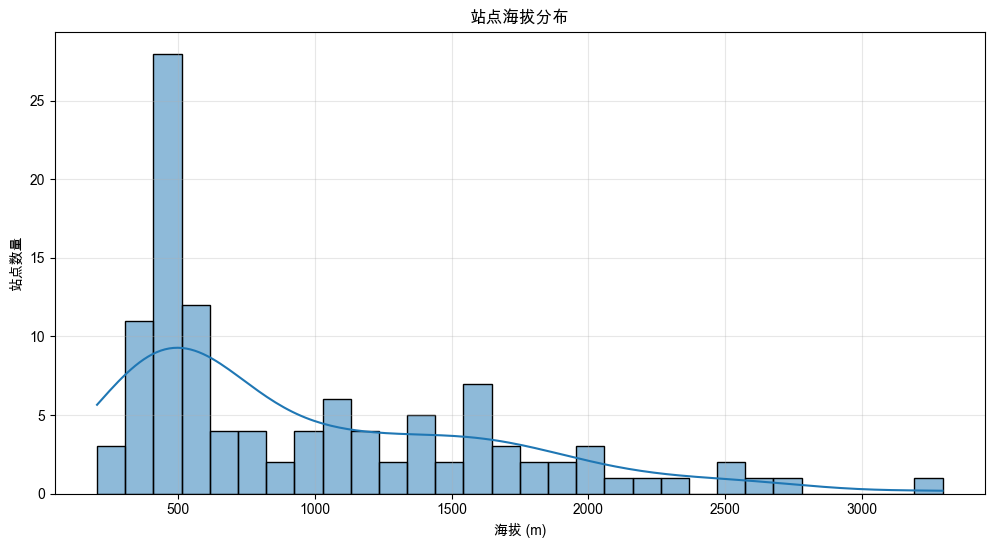

海拔统计信息:
count     112.000000
mean      973.309875
std       662.183630
min       203.200000
25%       454.000000
50%       645.015000
75%      1425.775000
max      3294.310000
Name: station_height, dtype: float64


In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(matched_geo_df['station_height'], bins=30, kde=True)
plt.title('站点海拔分布')
plt.xlabel('海拔 (m)')
plt.ylabel('站点数量')
plt.grid(True, alpha=0.3)
plt.show()

# 海拔统计信息
print('海拔统计信息:')
print(matched_geo_df['station_height'].describe())

## 4. 站点类型分布

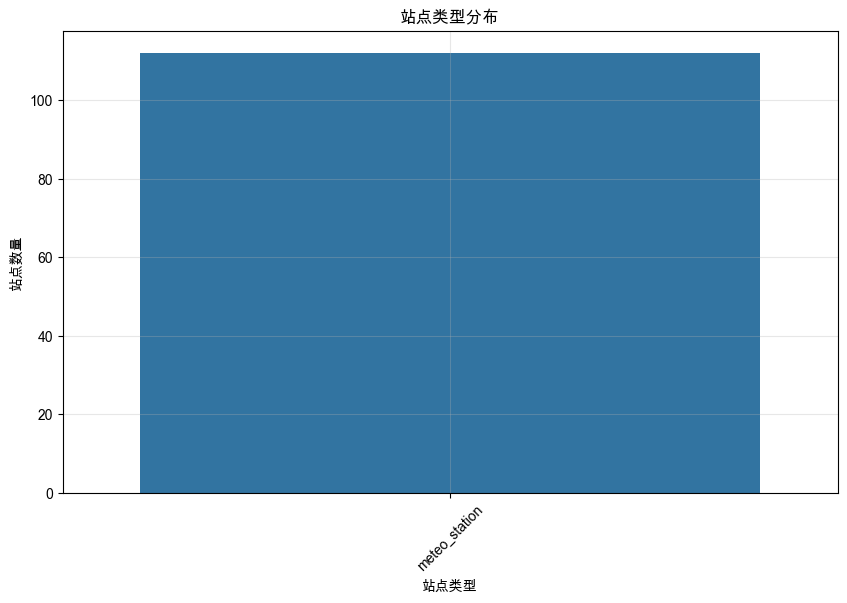

站点类型统计:
station_type
meteo_station    112
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(10, 6))
station_type_counts = matched_geo_df['station_type'].value_counts()
sns.barplot(x=station_type_counts.index, y=station_type_counts.values)
plt.title('站点类型分布')
plt.xlabel('站点类型')
plt.ylabel('站点数量')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

print('站点类型统计:')
print(station_type_counts)

## 5. 气象数据覆盖分析

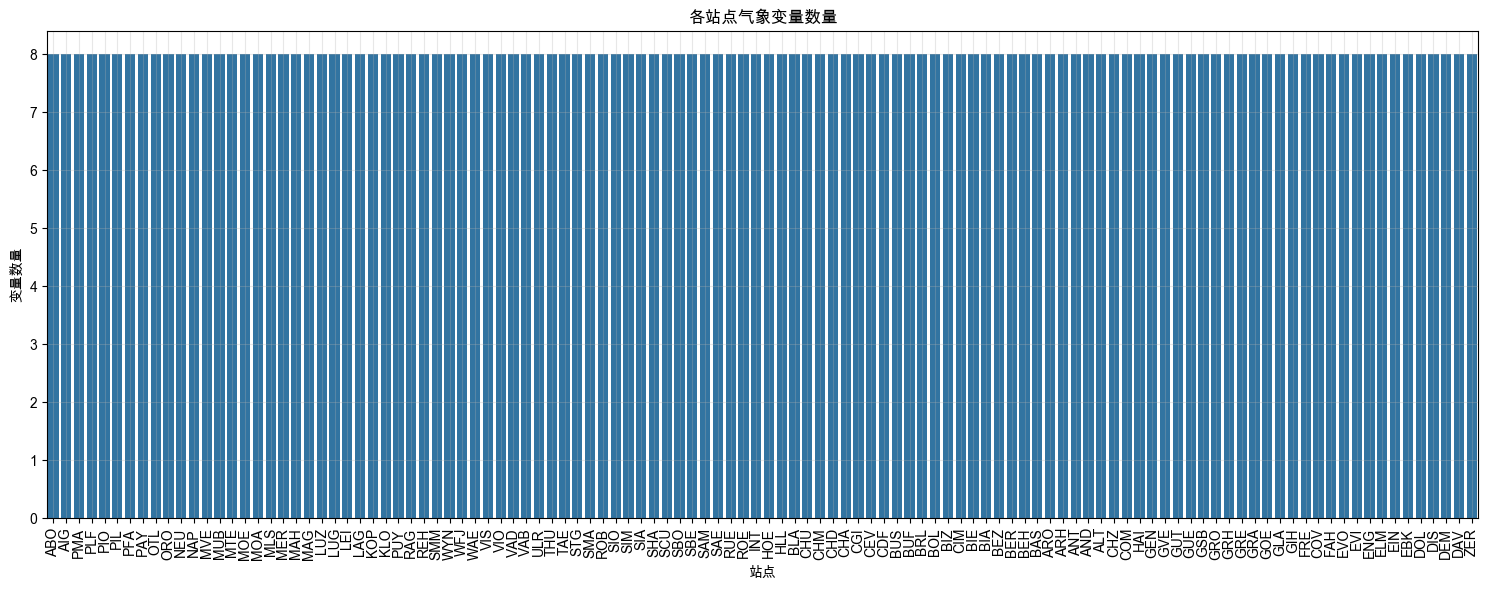

变量数量统计:
count    112.0
mean       8.0
std        0.0
min        8.0
25%        8.0
50%        8.0
75%        8.0
max        8.0
Name: var_count, dtype: float64


In [ ]:
# 分析每个站点的气象变量数量
station_vars = {}
for col in meteo_df.columns:
    station_code = col.split('~')[0]
    var_name = col.split('~')[1]
    if station_code not in station_vars:
        station_vars[station_code] = []
    station_vars[station_code].append(var_name)

# 创建变量数量统计
var_count_df = pd.DataFrame({
    'station': list(station_vars.keys()),
    'var_count': [len(vars) for vars in station_vars.values()]
})

# 按变量数量排序
var_count_df = var_count_df.sort_values('var_count', ascending=False)

plt.figure(figsize=(15, 6))
sns.barplot(x='station', y='var_count', data=var_count_df)
plt.title('各站点气象变量数量')
plt.xlabel('站点')
plt.ylabel('变量数量')
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 变量数量统计
print('变量数量统计:')
print(var_count_df['var_count'].describe())

## 6. 站点空间密度分析

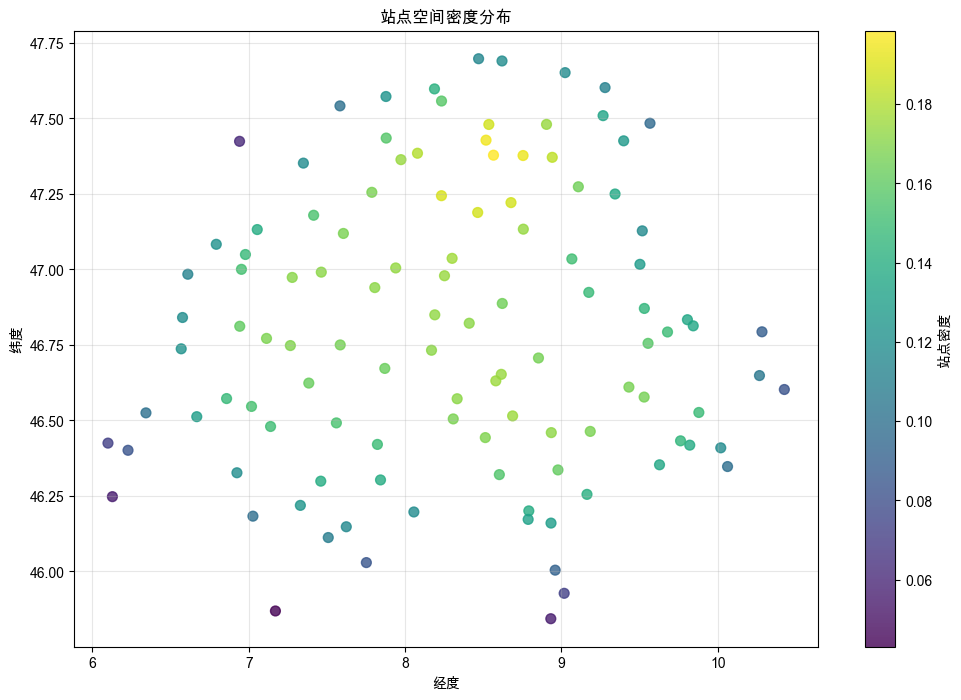

In [ ]:
from scipy.stats import gaussian_kde

# 计算核密度估计
x = matched_geo_df['longitude']
y = matched_geo_df['latitude']
xy = np.vstack([x, y])
kde = gaussian_kde(xy)
z = kde(xy)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(x, y, c=z, s=50, cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='站点密度')
plt.title('站点空间密度分布')
plt.xlabel('经度')
plt.ylabel('纬度')
plt.grid(True, alpha=0.3)
plt.show()

## 7. 海拔与站点类型关系

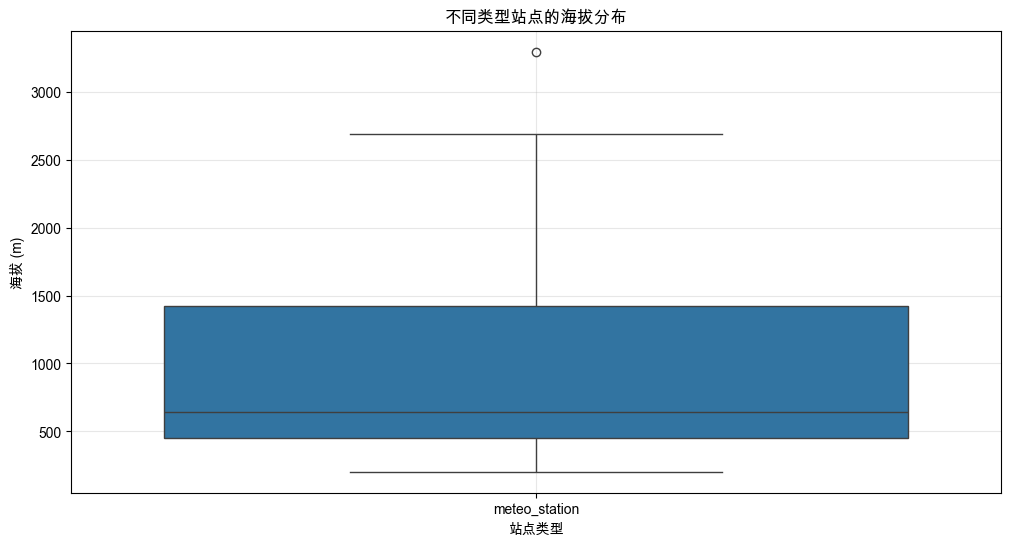

各类型站点海拔统计:
               count        mean        std    min    25%      50%       75%  \
station_type                                                                   
meteo_station  112.0  973.309875  662.18363  203.2  454.0  645.015  1425.775   

                   max  
station_type            
meteo_station  3294.31  


In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='station_type', y='station_height', data=matched_geo_df)
plt.title('不同类型站点的海拔分布')
plt.xlabel('站点类型')
plt.ylabel('海拔 (m)')
plt.grid(True, alpha=0.3)
plt.show()

# 按类型统计海拔
print('各类型站点海拔统计:')
print(matched_geo_df.groupby('station_type')['station_height'].describe())

## 8. 分析总结

In [ ]:
print('=== 分析总结 ===')
print(f'1. 气象数据包含站点数: {len(stations_in_meteo)}')
print(f'2. 匹配的地理数据站点数: {len(matched_geo_df)}')
print(f'3. 站点类型分布:')
for station_type, count in station_type_counts.items():
    print(f'   - {station_type}: {count}个')
print(f'4. 海拔范围: {matched_geo_df['station_height'].min():.1f}m - {matched_geo_df['station_height'].max():.1f}m')
print(f'5. 平均海拔: {matched_geo_df['station_height'].mean():.1f}m')
print(f'6. 每个站点平均变量数: {var_count_df['var_count'].mean():.1f}')

=== 分析总结 ===
1. 气象数据包含站点数: 112
2. 匹配的地理数据站点数: 112
3. 站点类型分布:
   - meteo_station: 112个
4. 海拔范围: 203.2m - 3294.3m
5. 平均海拔: 973.3m
6. 每个站点平均变量数: 8.0
